Ingrese el nombre del archivo de imagen (incluyendo la extensión): /content/RX mano con fisura.jpeg


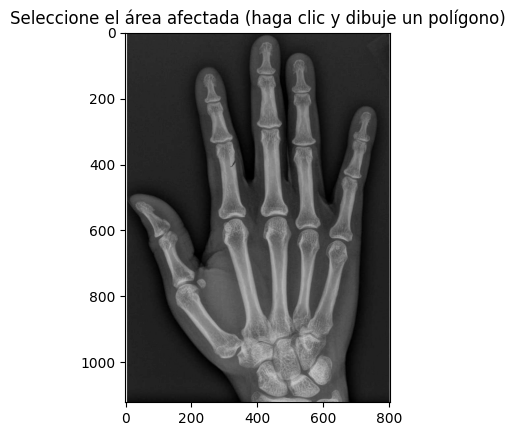

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def cargarImagen():
    # Cargar la imagen
    filename = input("Ingrese el nombre del archivo de imagen (incluyendo la extensión): ")
    img = cv2.imread(filename)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Mostrar la imagen original y seleccionar el área afectada
    plt.figure()
    plt.imshow(img_gray, cmap='gray')
    plt.title('Seleccione el área afectada (haga clic y dibuje un polígono)')
    plt.show()

    mask = plt.ginput(n=0, timeout=0)
    mask = np.array(mask, dtype=np.int32)

    # Crear una máscara a partir de la selección
    mask_img = np.zeros_like(img_gray, dtype=np.uint8)
    cv2.fillPoly(mask_img, [mask], 255)

    # Aplicar la máscara a la imagen original
    I_crop = cv2.bitwise_and(img_gray, img_gray, mask=mask_img)

    # Aplicar un filtro de Sobel para detectar bordes en el área seleccionada
    edges = cv2.Canny(I_crop, 50, 150)

    # Aplicar operaciones morfológicas para resaltar la fisura
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    dilated = cv2.dilate(edges, se)
    filled = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, se)
    eroded = cv2.erode(filled, se)

    # Crear una imagen en color para resaltar la fisura en rojo
    img_color = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    img_color[eroded > 0, :] = [0, 0, 255]

    # Mostrar la imagen con la fisura resaltada
    plt.figure(figsize=(10, 7))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Imagen Original')

    plt.subplot(1, 3, 2)
    plt.imshow(I_crop, cmap='gray')
    plt.title('Área Seleccionada')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    plt.title('Fisura Resaltada')
    plt.show()

# Llamar a la función para cargar la imagen
cargarImagen()
